# Task 4: Data Storytelling & Statistical Validation
This notebook validates the cleaned e-commerce dataset, explores key trends, and performs a hypothesis test using `scipy`.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, levene

sns.set(style="whitegrid")

# Load cleaned dataset
df = pd.read_csv("Data_Wrangling/Task1_Data_Wrangling/cleaned_dataset.csv")
df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")

df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales
0,Ord100002,2025-02-25,Cust5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39
1,Ord100003,2025-10-14,Cust3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80
2,Ord100004,2025-05-13,Cust8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48
3,Ord100005,2025-12-02,Cust2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24
4,Ord100006,2025-11-20,Cust4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90


## Data Validation
Check for missing values, duplicates, and basic structure in the cleaned dataset.

In [12]:
print("Dataset shape:", df.shape)
print("\nMissing values by column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nGender distribution:")
print(df["Gender"].value_counts())
print("\nCategory distribution:")
print(df["Category"].value_counts())

Dataset shape: (1000, 12)

Missing values by column:
Order_ID         0
Order_Date       0
Customer_ID      0
Customer_Name    0
Age              0
Gender           0
City             0
Product          0
Category         0
Quantity         0
Unit_Price       0
Total_Sales      0
dtype: int64

Duplicate rows: 0

Gender distribution:
Gender
Male      511
Female    489
Name: count, dtype: int64

Category distribution:
Category
Electronics    354
Education      178
Furniture      159
Fashion        156
Grocery        153
Name: count, dtype: int64


## Summary Statistics
This section documents the numeric summary for sales, quantity, and pricing.

In [13]:
summary = df[["Age", "Quantity", "Unit_Price", "Total_Sales"]].describe().T
summary["range"] = summary["max"] - summary["min"]
summary

,count,mean,std,min,25%,50%,75%,max,range
Age,1000.0,41.360204,13.683533,18.00,30.0000,41.000,53.0000,65.00,47.00
Quantity,1000.0,5.435000,2.838632,1.00,3.0000,5.000,8.0000,10.00,9.00
Unit_Price,1000.0,25486.783410,14179.402361,145.78,13895.7225,25398.740,37512.3825,49997.53,49851.75
Total_Sales,1000.0,139399.439650,114100.051546,437.34,47066.6325,108594.025,203722.8825,493677.50,493240.16


## Exploratory Data Analysis
Visualize category performance, city revenue, and the relationships between sales features.

C:\Users\Sanjay Rahul\AppData\Local\Temp\ipykernel_2932\2799742198.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_sales.index, y=category_sales.values, palette="viridis")


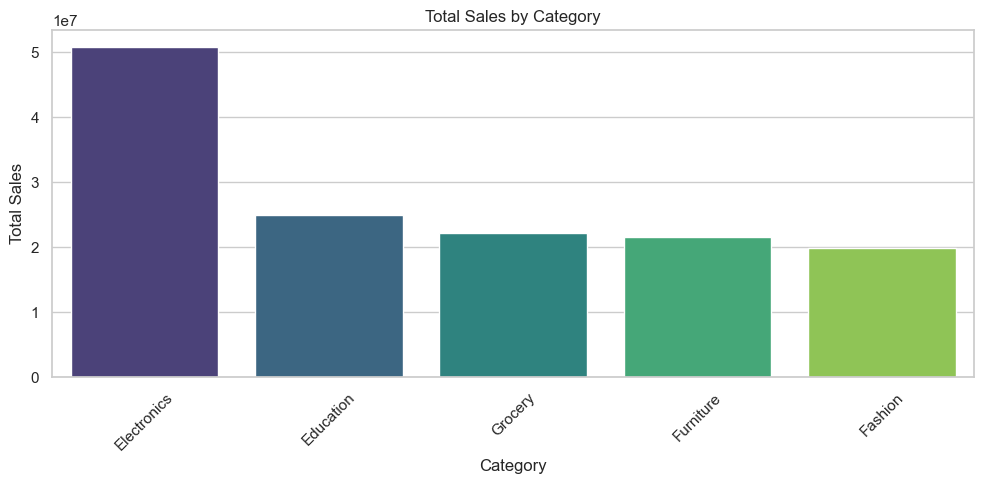

C:\Users\Sanjay Rahul\AppData\Local\Temp\ipykernel_2932\2799742198.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_sales.index, y=city_sales.values, palette="magma")


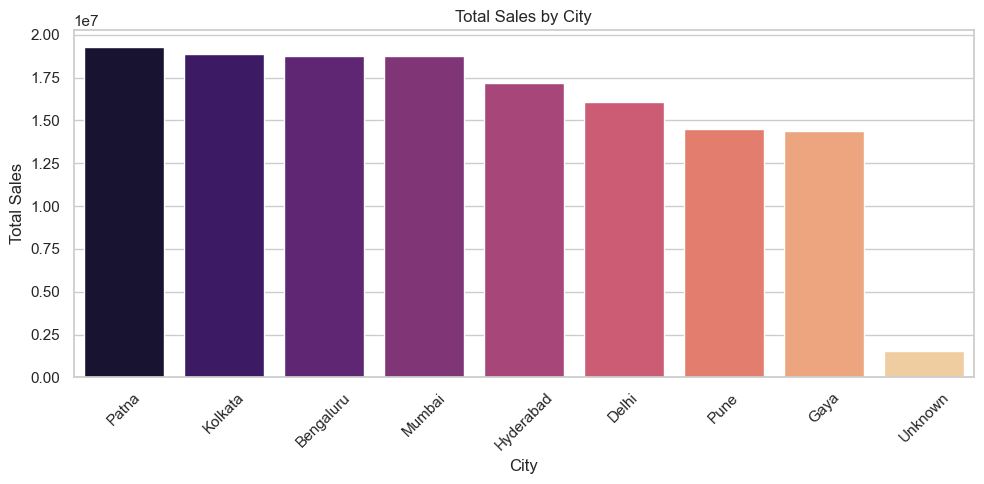

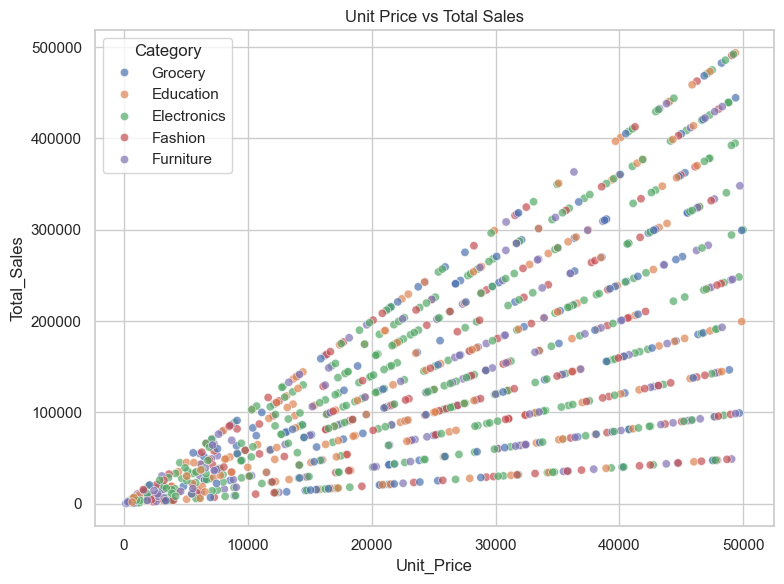

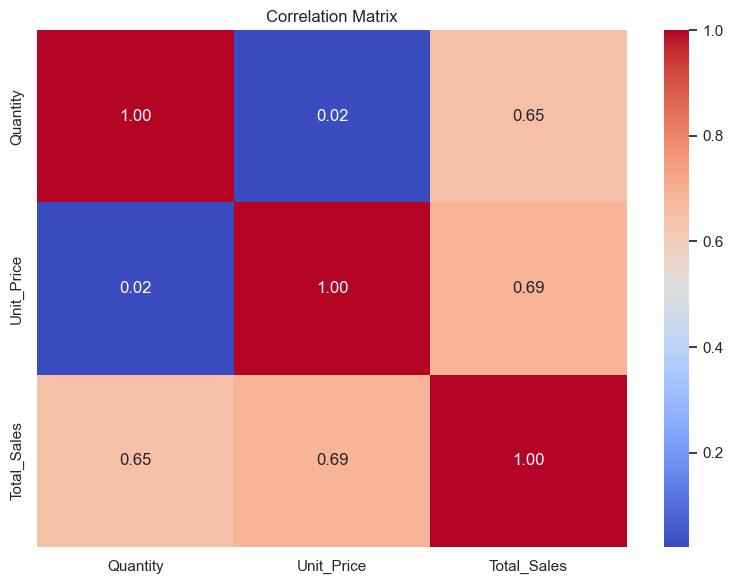

In [14]:
plt.figure(figsize=(10, 5))
category_sales = df.groupby("Category")["Total_Sales"].sum().sort_values(ascending=False)
sns.barplot(x=category_sales.index, y=category_sales.values, palette="viridis")
plt.title("Total Sales by Category")
plt.ylabel("Total Sales")
plt.xlabel("Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
city_sales = df.groupby("City")["Total_Sales"].sum().sort_values(ascending=False)
sns.barplot(x=city_sales.index, y=city_sales.values, palette="magma")
plt.title("Total Sales by City")
plt.ylabel("Total Sales")
plt.xlabel("City")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Unit_Price", y="Total_Sales", hue="Category", alpha=0.7)
plt.title("Unit Price vs Total Sales")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(df[["Quantity", "Unit_Price", "Total_Sales"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## Statistical Validation
Test whether average `Total_Sales` differs between male and female customers using Welch's t-test.

In [15]:
male_sales = df[df["Gender"] == "Male"]["Total_Sales"]
female_sales = df[df["Gender"] == "Female"]["Total_Sales"]

levene_result = levene(male_sales, female_sales)
stat_result = ttest_ind(male_sales, female_sales, equal_var=False)

print("Male average Total Sales:", round(male_sales.mean(), 2))
print("Female average Total Sales:", round(female_sales.mean(), 2))
print("\nLevene's test p-value:", round(levene_result.pvalue, 4))
print("Welch's t-test statistic:", round(stat_result.statistic, 4))
print("Welch's t-test p-value:", round(stat_result.pvalue, 4))

if stat_result.pvalue < 0.05:
    print("\nResult: statistically significant difference in average Total Sales by gender.")
else:
    print("\nResult: no statistically significant difference in average Total Sales by gender.")

Male average Total Sales: 141807.34
Female average Total Sales: 136883.21

Levene's test p-value: 0.3281
Welch's t-test statistic: 0.6826
Welch's t-test p-value: 0.495

Result: no statistically significant difference in average Total Sales by gender.


## Final Business Conclusion
- The cleaned dataset is validated and ready for analysis.
- `Electronics` generates the highest total revenue, while `Grocery` leads average order value.
- `Patna`, `Kolkata`, and `Bengaluru` are the strongest revenue cities.
- Gender does not have a statistically significant effect on average order value, so business action should focus on category and geographic segmentation.
- Use these insights to drive promotional focus toward high-value categories and high-performing cities.